# Map Snapshot From `Nulling_CDF`

This notebook reuses the parameter settings from `Nulling_CDF.ipynb`,
automatically resamples a single Monte Carlo snapshot until every BS sector has at least one TN pair,
and then outputs:

1. The initial drop map
2. A map of the NTN users detected by `MUSIC` and the round-0 paired TN users
3. A detected-NTN + paired-TN map based on `layout1.png`
4. Three radio maps
   - no nulling
   - MUSIC estimated `(u, g)` nulling
   - true `(u, g)` nulling

The notebook is bound to the `sionna_gpu` kernel by default, and the rendering parameters are set to a medium configuration that can be executed directly. Increase them only if you need finer-grained figures.

In [1]:
import importlib
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sionna.rt import Camera, RadioMapSolver, Receiver, load_scene

try:
    from sionna.rt import transform_mesh
except Exception:
    transform_mesh = None

import SceneConfigSionna
import nulling_cdf_utils as ncu

importlib.reload(SceneConfigSionna)
importlib.reload(ncu)

from SceneConfigSionna import SceneConfigSionna
from ntn_music_detection import collapse_cir_to_narrowband, run_music_standard_pipeline

plt.rcParams.update(
    {
        "figure.figsize": (8.0, 6.0),
        "axes.grid": False,
        "font.size": 10,
    }
)

In [2]:
# ---- Shared configuration (mirrors Nulling_CDF.ipynb, but runs one snapshot only) ----
scene_path = Path("Denver_scene/10kmwithfigure/10km.xml")
result_dir = Path("result") / "map_snapshot"
result_dir.mkdir(parents=True, exist_ok=True)

# Set to integers if you want reproducible drops.
# Keep as None if you want fresh TN/NTN/satellite positions every run.
layout_rng_seed_base = None
satellite_rng_seed_base = None
max_drop_attempts = 40
layout_image_path = Path("Denver_scene/10kmwithfigure/layout1.png")

# Geometry and deployment
ntn_rx = 100
tn_rx = 300
bs_row = 2
bs_col = 2
nbs = bs_row * bs_col
nsect = 3

satellite_azimuth_range_deg = (0.0, 360.0)
satellite_elevation_range_deg = (45.0, 90.0)
# Carrier and array configuration
fc = 9.99e9
tx_antenna_rows = 8
tx_antenna_cols = 8
tn_rx_antenna_rows = 1
tn_rx_antenna_cols = 1
tx_antennas = tx_antenna_rows * tx_antenna_cols

# TX sector orientation
tx_sector_yaw_offset_deg = 0.0
tx_head_down_deg = 3.0
tx_sector_roll_deg = 0.0

tx_sector_yaw_offset_rad = np.deg2rad(tx_sector_yaw_offset_deg)
tx_sector_pitch_rad = -np.deg2rad(tx_head_down_deg)
tx_sector_roll_rad = np.deg2rad(tx_sector_roll_deg)

# Noise and thresholds
EkT = -174
B = 100e6
Tx_power_dbm = 35
Tx_power = 10 ** ((Tx_power_dbm - 30) / 10)
Tx_power_handheld_dbm = 23
Tx_power_handheld = 10 ** ((Tx_power_handheld_dbm - 30) / 10)

NF = 7
NF_vsat = 3
NF_bs = 2
N0_dBm = EkT + 10 * np.log10(B) + NF
N0 = 10 ** ((N0_dBm - 30) / 10)
N0_vsat = 10 ** ((EkT + 10 * np.log10(B) + NF_vsat - 30) / 10)
N0_bs = 10 ** ((EkT + 10 * np.log10(B) + NF_bs - 30) / 10)

snr_threshold = -6
inr_threshold = -6
h_ntn_th = np.sqrt(10 ** (inr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
h_tn_th = np.sqrt(10 ** (snr_threshold / 10) * N0_bs * tx_antennas / Tx_power)

# MUSIC configuration
music_threshold = 3
music_covariance_mode = "sample"
music_num_snapshots = 200
music_noise_var = N0_bs / Tx_power
music_rng_seed = 7
music_source_estimation = "mdl"
music_energy_ratio = 0.95
music_reduce_ntn_ant = "max"
music_user_powers = None
music_use_sector_orientation = True
music_sector_pitch_rad = float(tx_sector_pitch_rad)
music_sector_roll_rad = float(tx_sector_roll_rad)
music_rotation_order = "zyx"
music_std_channel_mode = "conj"
music_std_manifold_label = "yz:+1"
music_std_flatten_order = "F"
music_std_scan_mode = "complex"
music_std_phi_offset_deg = 0.0
music_std_phi_mirror_about_sector = False
music_std_horizontal_sign = -1
music_sector_forward_only = True
music_sector_forward_cos_min = 0.0
music_phi_grid_deg = np.arange(0.0, 360.0, 1.0)
music_theta_grid_deg = np.arange(0.0, 181.0, 1.0)

# Render one lambda for the map triplet
lambda_render = float(1e15)
max_detected_b_terms = "all"

compute_positions_kwargs = dict(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    centerBS=False,
    bs_grid=(bs_row, bs_col),
    bs_boundary=2500,
    tn_building_ratio=0.6,
    tn_distance=400,
    ntn_building_ratio=0.8,
    plot_grid=False,
    plot_bs=False,
    plot_tn=False,
    plot_ntn=False,
)

compute_paths_kwargs = dict(
    nsect=nsect,
    fc=fc,
    tx_rows=tx_antenna_rows,
    tx_cols=tx_antenna_cols,
    tn_rx_rows=tn_rx_antenna_rows,
    tn_rx_cols=tn_rx_antenna_cols,
    max_depth=0,
    bandwidth=B,
    tx_power_dbm=Tx_power_dbm,
    sector_yaw_offset_rad=tx_sector_yaw_offset_rad,
    sector_pitch_rad=tx_sector_pitch_rad,
    sector_roll_rad=tx_sector_roll_rad,
)

music_kwargs = dict(
    tx_rows=int(tx_antenna_rows),
    tx_cols=int(tx_antenna_cols),
    nsect=int(nsect),
    pair_keys=None,
    detect_num_sources=None,
    detect_threshold=music_threshold,
    detect_user_powers=music_user_powers,
    detect_noise_var=music_noise_var,
    detect_covariance_mode=music_covariance_mode,
    detect_num_snapshots=music_num_snapshots,
    detect_rng_seed=music_rng_seed,
    detect_source_estimation=music_source_estimation,
    detect_energy_ratio=music_energy_ratio,
    detect_reduce_rx_ant=music_reduce_ntn_ant,
    channel_mode=music_std_channel_mode,
    manifold_label=music_std_manifold_label,
    flatten_order=music_std_flatten_order,
    scan_mode=music_std_scan_mode,
    phi_offset_deg=music_std_phi_offset_deg,
    phi_mirror_about_sector=music_std_phi_mirror_about_sector,
    steering_horizontal_sign=music_std_horizontal_sign,
    use_sector_orientation=music_use_sector_orientation,
    sector_pitch_rad=music_sector_pitch_rad,
    sector_roll_rad=music_sector_roll_rad,
    rotation_order=music_rotation_order,
    sector_forward_only=music_sector_forward_only,
    sector_forward_cos_min=music_sector_forward_cos_min,
    phi_grid_deg=music_phi_grid_deg,
    theta_grid_deg=music_theta_grid_deg,
)

print(f"scene_path = {scene_path}")
print(f"layout seed base (user) = {layout_rng_seed_base}")
print(f"satellite seed base (user) = {satellite_rng_seed_base}")
print(f"max_drop_attempts = {max_drop_attempts}")
print(
    "satellite search range = "
    f"az {satellite_azimuth_range_deg}, el {satellite_elevation_range_deg}"
)
print(f"lambda_render = {lambda_render:.2e}")

scene_path = Denver_scene/10kmwithfigure/10km.xml
layout seed base (user) = None
satellite seed base (user) = None
max_drop_attempts = 40
satellite search range = az (0.0, 360.0), el (45.0, 90.0)
lambda_render = 1.00e+15


In [3]:
scene = load_scene(str(scene_path))
SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)

def _resolve_base_seed(user_seed):
    if user_seed is None:
        return int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
    return int(user_seed)

layout_seed_base_resolved = _resolve_base_seed(layout_rng_seed_base)
satellite_seed_base_resolved = _resolve_base_seed(satellite_rng_seed_base)
print(f"layout seed base (resolved) = {layout_seed_base_resolved}")
print(f"satellite seed base (resolved) = {satellite_seed_base_resolved}")

selected_attempt_idx = None
selected_layout_seed = None
selected_satellite_seed = None

for attempt_idx in range(int(max_drop_attempts)):
    layout_seed = int(layout_seed_base_resolved) + int(attempt_idx)
    satellite_seed = int(satellite_seed_base_resolved) + int(attempt_idx)
    np.random.seed(layout_seed)
    sat_rng = np.random.default_rng(satellite_seed)
    azimuth = float(sat_rng.uniform(*satellite_azimuth_range_deg))
    elevation = float(sat_rng.uniform(*satellite_elevation_range_deg))

    compute_positions_kwargs_try = dict(compute_positions_kwargs)
    compute_positions_kwargs_try["azimuth"] = azimuth
    compute_positions_kwargs_try["elevation"] = elevation

    SceneConfig.compute_positions(**compute_positions_kwargs_try)
    SceneConfig.compute_paths(**compute_paths_kwargs)

    h_tn_all = collapse_cir_to_narrowband(SceneConfig.a_tn)
    h_ntn_all = collapse_cir_to_narrowband(SceneConfig.a_ntn)

    pairing = ncu.pair_tn_to_strongest_tx(
        h_tn_all,
        h_tn_th=h_tn_th,
        tx_antennas=tx_antennas,
        tx_power=Tx_power,
        snr_noise_power=N0,
    )

    print(
        f"attempt {attempt_idx:02d}: "
        f"layout_seed={layout_seed}, sat_seed={satellite_seed}, "
        f"az={azimuth:.2f}, el={elevation:.2f}, "
        f"min_count={int(pairing['min_count'])}"
    )
    if int(pairing["min_count"]) >= 1:
        selected_attempt_idx = int(attempt_idx)
        selected_layout_seed = int(layout_seed)
        selected_satellite_seed = int(satellite_seed)
        break

if selected_attempt_idx is None:
    raise RuntimeError(
        "Failed to find a snapshot with at least one TN pair in every BS sector "
        f"after {int(max_drop_attempts)} attempts."
    )

ntn_music_out = run_music_standard_pipeline(
    h_ntn_all,
    **music_kwargs,
)
music_lookup = ncu.build_music_tx_lookup(
    ntn_music_out,
    num_ntn_rx=int(h_ntn_all.shape[0]),
    num_tx_total=int(h_ntn_all.shape[2]),
    num_tx_ant=int(h_ntn_all.shape[3]),
)

round_out = ncu.run_small_round(
    h_tn_all,
    h_ntn_all,
    pairs_by_tx=pairing["pairs_by_tx"],
    music_lookup=music_lookup,
    round_idx=0,
    lambda_ranges=None,
    lambda_ranges_music_est=[lambda_render],
    lambda_ranges_music_real=[lambda_render],
    tx_power=Tx_power,
    snr_noise_power=N0,
    inr_noise_power=N0_vsat,
    max_detected_b_terms=max_detected_b_terms,
)

detected_ntn_idx = np.flatnonzero(np.asarray(round_out["detected_mask"], dtype=bool))
eval_ntn_idx = np.flatnonzero(np.asarray(round_out["eval_mask"], dtype=bool))
paired_tx_idx = np.array(sorted(round_out["round_pairs"].keys()), dtype=int)
paired_bs_idx = np.array([int(tx_idx) // int(nsect) for tx_idx in paired_tx_idx], dtype=int)
paired_tn_idx = np.array(
    [int(round_out["round_pairs"][int(tx_idx)]["tn_idx"]) for tx_idx in paired_tx_idx],
    dtype=int,
)

detected_ntn_pos = (
    np.asarray(SceneConfig.rx_ntn_pos, dtype=float)[detected_ntn_idx]
    if detected_ntn_idx.size > 0
    else np.empty((0, 3), dtype=float)
)
paired_tn_pos = (
    np.asarray(SceneConfig.tn_pos, dtype=float)[paired_tn_idx]
    if paired_tn_idx.size > 0
    else np.empty((0, 3), dtype=float)
)

lambda_key = float(lambda_render)
raw_precoding = ncu.build_precoding_matrix_from_tx_beams(
    SceneConfig.tx_name_list,
    round_out["raw_beams"],
    nsect=nsect,
    num_tx_ant=tx_antennas,
)
music_est_precoding = ncu.build_precoding_matrix_from_tx_beams(
    SceneConfig.tx_name_list,
    round_out["est_beams"][lambda_key],
    nsect=nsect,
    num_tx_ant=tx_antennas,
)
music_true_precoding = ncu.build_precoding_matrix_from_tx_beams(
    SceneConfig.tx_name_list,
    round_out["music_real_beams"][lambda_key],
    nsect=nsect,
    num_tx_ant=tx_antennas,
)

print(f"selected attempt = {selected_attempt_idx}")
print(f"selected layout seed = {selected_layout_seed}")
print(f"selected satellite seed = {selected_satellite_seed}")
print(f"selected satellite az/el = ({azimuth:.2f}, {elevation:.2f}) deg")
print("min_count across all BS sectors:", int(pairing["min_count"]))
print("detected NTN count:", detected_ntn_idx.size)
print("eval NTN count (true u,g subset):", eval_ntn_idx.size)
print("round-0 paired TN count:", paired_tn_idx.size)
print("raw SNR mean:", float(np.mean(round_out["raw_snr_db"])))
print("MUSIC-est SNR mean:", float(np.mean(round_out["est_snr_db"][lambda_key])))
print("True-u,g SNR mean:", float(np.mean(round_out["music_real_snr_db"][lambda_key])))

x range: [-5052.669, 5027.331]
y range: [-5046.508, 5043.492]
layout seed base (resolved) = 2591329679
satellite seed base (resolved) = 820367268
attempt 00: layout_seed=2591329679, sat_seed=820367268, az=28.05, el=56.83, min_count=3
selected attempt = 0
selected layout seed = 2591329679
selected satellite seed = 820367268
selected satellite az/el = (28.05, 56.83) deg
min_count across all BS sectors: 3
detected NTN count: 61
eval NTN count (true u,g subset): 61
round-0 paired TN count: 12
raw SNR mean: 32.00885284972706
MUSIC-est SNR mean: 16.972982671990092
True-u,g SNR mean: 15.46952381153901


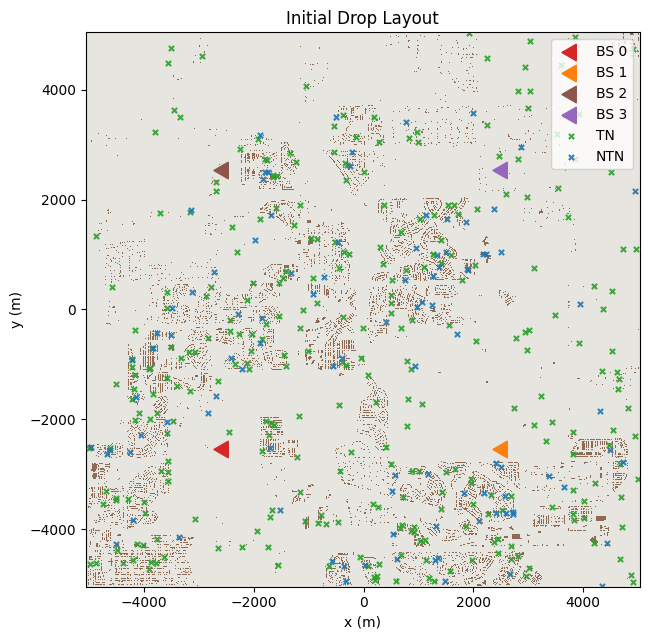

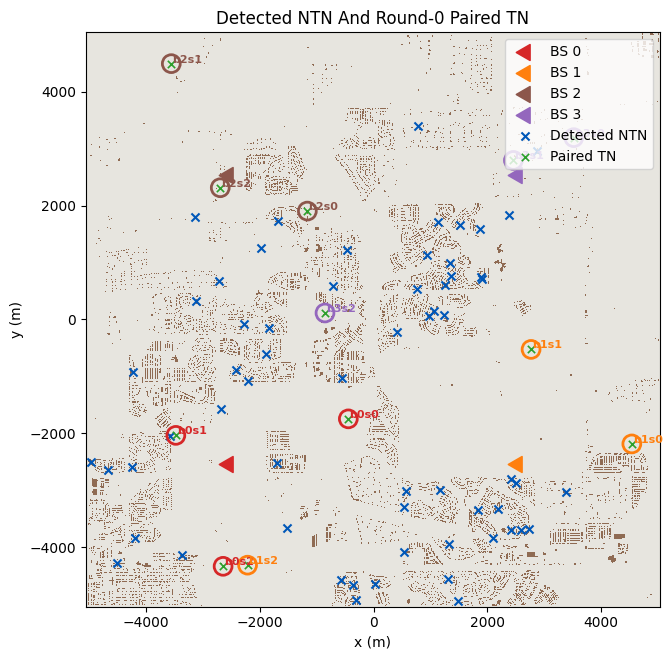

In [4]:
def _bs_color_map(scene_config):
    palette = ["#d62728", "#ff7f0e", "#8c564b", "#9467bd", "#7f7f7f", "#bcbd22"]
    return {
        int(bs_idx): palette[int(bs_idx) % len(palette)]
        for bs_idx in range(int(scene_config.tx_pos.shape[0]))
    }


def plot_initial_drop(scene_config):
    fig, ax = plt.subplots(figsize=(8.2, 6.5))
    cmap_bg = ListedColormap(["#e7e5df", "#8f6b53"])
    bs_colors = _bs_color_map(scene_config)

    ax.imshow(
        scene_config.point_type,
        cmap=cmap_bg,
        interpolation="nearest",
        extent=scene_config.extent,
    )

    for bs_idx in range(int(scene_config.tx_pos.shape[0])):
        ax.scatter(
            [scene_config.tx_pos[bs_idx, 0]],
            [scene_config.tx_pos[bs_idx, 1]],
            c=[bs_colors[int(bs_idx)]],
            marker=(3, 0, -30),
            s=180,
            linewidths=1.2,
            label=f"BS {int(bs_idx)}",
        )
    ax.scatter(
        scene_config.tn_pos[:, 0],
        scene_config.tn_pos[:, 1],
        c="#2ca02c",
        marker="x",
        s=14,
        alpha=0.9,
        label="TN",
    )
    ax.scatter(
        scene_config.rx_ntn_pos[:, 0],
        scene_config.rx_ntn_pos[:, 1],
        c="#1f77b4",
        marker="x",
        s=14,
        alpha=0.9,
        label="NTN",
    )

    ax.set_title("Initial Drop Layout")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper right", frameon=True)
    fig.tight_layout()
    fig.savefig(result_dir / "layout_initial_drop.png", dpi=220, bbox_inches="tight")
    plt.show()


def plot_detected_and_paired(scene_config, detected_idx, paired_idx, paired_tx, paired_bs):
    fig, ax = plt.subplots(figsize=(8.4, 6.7))
    cmap_bg = ListedColormap(["#e7e5df", "#8f6b53"])
    bs_colors = _bs_color_map(scene_config)

    ax.imshow(
        scene_config.point_type,
        cmap=cmap_bg,
        interpolation="nearest",
        extent=scene_config.extent,
    )

    for bs_idx in range(int(scene_config.tx_pos.shape[0])):
        ax.scatter(
            [scene_config.tx_pos[bs_idx, 0]],
            [scene_config.tx_pos[bs_idx, 1]],
            c=[bs_colors[int(bs_idx)]],
            marker=(3, 0, -30),
            s=170,
            linewidths=1.2,
            label=f"BS {int(bs_idx)}",
        )

    if detected_idx.size > 0:
        ax.scatter(
            scene_config.rx_ntn_pos[detected_idx, 0],
            scene_config.rx_ntn_pos[detected_idx, 1],
            c="#0057b8",
            marker="x",
            s=34,
            linewidths=1.5,
            label="Detected NTN",
        )

    if paired_idx.size > 0:
        ax.scatter(
            scene_config.tn_pos[paired_idx, 0],
            scene_config.tn_pos[paired_idx, 1],
            c="#2ca02c",
            marker="x",
            s=28,
            linewidths=1.2,
            label="Paired TN",
        )

    for tn_idx, tx_idx, bs_idx in zip(
        paired_idx.tolist(),
        paired_tx.tolist(),
        paired_bs.tolist(),
    ):
        color = bs_colors[int(bs_idx)]
        x, y = scene_config.tn_pos[int(tn_idx), :2]
        ax.scatter(
            [x],
            [y],
            facecolors="none",
            edgecolors=[color],
            marker="o",
            s=165,
            linewidths=2.0,
        )
        ax.text(
            x + 18.0,
            y + 18.0,
            f"b{int(bs_idx)}s{int(tx_idx) % int(nsect)}",
            color=color,
            fontsize=8,
            weight="bold",
        )

    ax.set_title("Detected NTN And Round-0 Paired TN")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper right", frameon=True)
    fig.tight_layout()
    fig.savefig(result_dir / "layout_detected_and_paired.png", dpi=220, bbox_inches="tight")
    plt.show()


plot_initial_drop(SceneConfig)
plot_detected_and_paired(
    SceneConfig,
    detected_ntn_idx,
    paired_tn_idx,
    paired_tx_idx,
    paired_bs_idx,
)

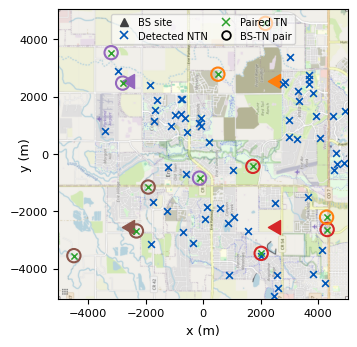

In [5]:
def _rotate_points_in_extent(xy, extent, rotation_deg_cw):
    rotation_deg_cw = int(rotation_deg_cw) % 360
    if rotation_deg_cw not in (0, 90, 180, 270):
        raise ValueError(f"rotation_deg_cw must be one of 0/90/180/270, got {rotation_deg_cw}")

    xy = np.asarray(xy, dtype=float)
    if xy.size == 0:
        return xy.reshape(-1, 2)

    xmin, xmax, ymin, ymax = map(float, extent)
    width = xmax - xmin
    height = ymax - ymin
    u = (xy[:, 0] - xmin) / width
    v = (xy[:, 1] - ymin) / height

    if rotation_deg_cw == 0:
        u_rot, v_rot = u, v
    elif rotation_deg_cw == 90:
        u_rot, v_rot = v, 1.0 - u
    elif rotation_deg_cw == 180:
        u_rot, v_rot = 1.0 - u, 1.0 - v
    else:  # 270
        u_rot, v_rot = 1.0 - v, u

    x_rot = xmin + u_rot * width
    y_rot = ymin + v_rot * height
    return np.column_stack([x_rot, y_rot])


def plot_detected_and_paired_with_layout_image(
    scene_config,
    image_path,
    detected_idx,
    paired_idx,
    paired_tx,
    paired_bs,
    rotation_deg_cw=0,
    save_name="layout_detected_and_paired_layout1.png",
    figure_width_in=3.45,
    show_bs_labels=False,
):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Background image not found: {image_path}")

    bg_img = plt.imread(str(image_path))
    rotation_deg_cw = int(rotation_deg_cw) % 360
    if rotation_deg_cw not in (0, 90, 180, 270):
        raise ValueError(f"rotation_deg_cw must be one of 0/90/180/270, got {rotation_deg_cw}")

    if rotation_deg_cw != 0:
        bg_img = np.rot90(bg_img, k=(-(rotation_deg_cw // 90)) % 4)

    bs_colors = _bs_color_map(scene_config)
    fig, ax = plt.subplots(figsize=(figure_width_in, figure_width_in))
    ax.imshow(bg_img, extent=scene_config.extent, aspect="auto")

    try:
        ax.set_box_aspect(1)
    except Exception:
        ax.set_aspect("equal", adjustable="box")

    tx_xy = _rotate_points_in_extent(scene_config.tx_pos[:, :2], scene_config.extent, rotation_deg_cw)
    ntn_xy = _rotate_points_in_extent(scene_config.rx_ntn_pos[:, :2], scene_config.extent, rotation_deg_cw)
    tn_xy = _rotate_points_in_extent(scene_config.tn_pos[:, :2], scene_config.extent, rotation_deg_cw)
    for bs_idx in range(int(scene_config.tx_pos.shape[0])):
        x_bs, y_bs = tx_xy[bs_idx, :2]
        ax.scatter(
            [x_bs],
            [y_bs],
            c=[bs_colors[int(bs_idx)]],
            marker=(3, 0, -30),
            s=135,
            linewidths=1.0,
        )
        if show_bs_labels:
            label_dx = 0.006 * (scene_config.extent[1] - scene_config.extent[0])
            label_dy = 0.006 * (scene_config.extent[3] - scene_config.extent[2])
            ax.text(
                x_bs + label_dx,
                y_bs + label_dy,
                f"{int(bs_idx)}",
                color=bs_colors[int(bs_idx)],
                fontsize=7.2,
                weight="bold",
                ha="left",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.12", facecolor="white", edgecolor="none", alpha=0.8),
            )

    if detected_idx.size > 0:
        ax.scatter(
            ntn_xy[detected_idx, 0],
            ntn_xy[detected_idx, 1],
            c="#0057b8",
            marker="x",
            s=24,
            linewidths=1.2,
        )

    if paired_idx.size > 0:
        ax.scatter(
            tn_xy[paired_idx, 0],
            tn_xy[paired_idx, 1],
            c="#2ca02c",
            marker="x",
            s=20,
            linewidths=1.1,
        )

    for tn_idx, _tx_idx, bs_idx in zip(
        paired_idx.tolist(),
        paired_tx.tolist(),
        paired_bs.tolist(),
    ):
        color = bs_colors[int(bs_idx)]
        x, y = tn_xy[int(tn_idx), :2]
        ax.scatter(
            [x],
            [y],
            facecolors="none",
            edgecolors=[color],
            marker="o",
            s=92,
            linewidths=1.5,
        )

    ax.set_xlabel("x (m)", fontsize=9.2)
    ax.set_ylabel("y (m)", fontsize=9.2)
    ax.yaxis.set_label_coords(-0.09, 0.5)
    ax.tick_params(axis="both", which="major", labelsize=8.2)
    ax.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="^",
                linestyle="None",
                color="0.25",
                markerfacecolor="0.25",
                markersize=5.8,
                label="BS site",
            ),
            Line2D(
                [0],
                [0],
                marker="x",
                linestyle="None",
                color="#0057b8",
                markersize=5.8,
                markeredgewidth=1.2,
                label="Detected NTN",
            ),
            Line2D(
                [0],
                [0],
                marker="x",
                linestyle="None",
                color="#2ca02c",
                markersize=5.4,
                markeredgewidth=1.1,
                label="Paired TN",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="None",
                color="black",
                markerfacecolor="none",
                markersize=6.2,
                markeredgewidth=1.3,
                label="BS-TN pair",
            ),
        ],
        loc="upper center",
        ncol=2,
        fontsize=7.2,
        frameon=True,
        framealpha=0.62,
        facecolor="white",
        edgecolor="0.75",
        borderpad=0.3,
        handletextpad=0.4,
        columnspacing=0.8,
        labelspacing=0.35,
    )
    fig.tight_layout(pad=0.3)
    fig.savefig(
        result_dir / save_name,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


layout_rotation_deg_cw = 270
plot_detected_and_paired_with_layout_image(
    SceneConfig,
    layout_image_path,
    detected_ntn_idx,
    paired_tn_idx,
    paired_tx_idx,
    paired_bs_idx,
    rotation_deg_cw=layout_rotation_deg_cw,
)

In [11]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D


def _cast_solver_seed(seed):
    if seed is None:
        return None
    for type_name in ("UInt", "UInt32", "UInt64"):
        t = getattr(mi, type_name, None)
        if t is not None:
            try:
                return t(int(seed))
            except Exception:
                pass
    try:
        import drjit as dr

        return dr.uint32(int(seed))
    except Exception:
        return int(seed)


def _patch_sampler_seed_compat(solver):
    sampler = getattr(solver, "_sampler", None)
    if sampler is None:
        return
    cls = sampler.__class__
    if getattr(cls, "_codex_seed_patched", False):
        return

    orig_seed = getattr(cls, "seed", None)
    if orig_seed is None:
        return

    def seed_compat(self, seed, wavefront_size=4294967295):
        try:
            return orig_seed(self, seed, int(wavefront_size))
        except TypeError:
            return orig_seed(self, seed)

    cls.seed = seed_compat
    cls._codex_seed_patched = True


def _get_terrain_mesh(scene_obj, terrain_name="terrain", z_offset=0.1):
    terrain = None
    if hasattr(scene_obj, "objects"):
        if terrain_name in scene_obj.objects:
            terrain = scene_obj.objects[terrain_name].clone(as_mesh=True)
        else:
            for name in scene_obj.objects.keys():
                if "terrain" in name.lower() or "plane" in name.lower():
                    terrain = scene_obj.objects[name].clone(as_mesh=True)
                    break
    if terrain is None:
        return None
    if transform_mesh is not None:
        try:
            transform_mesh(terrain, translation=[0, 0, z_offset])
        except Exception:
            pass
    return terrain


def _clear_scene_receivers(scene_obj):
    for rx_name in list(scene_obj.receivers):
        scene_obj.remove(rx_name)


def _compute_nulling_radiomap(
    scene_obj,
    precoding_matrix,
    *,
    cell_size=(20, 20),
    max_depth=2,
    samples_per_tx=2**13,
    use_terrain=True,
    terrain_name="terrain",
    terrain_z_offset=2.5,
    fallback_center=None,
    fallback_size=None,
    seed=1,
):
    _clear_scene_receivers(scene_obj)

    precoding = np.asarray(precoding_matrix, dtype=np.complex64)
    if precoding.ndim != 2:
        raise ValueError(f"precoding_matrix must be 2-D, got {precoding.shape}")

    nonzero_count = int(np.count_nonzero(np.linalg.norm(precoding, axis=1) > 0))
    print(f"TX total = {precoding.shape[0]}, nonzero precoders = {nonzero_count}")
    if nonzero_count == 0:
        raise RuntimeError("All precoding rows are zero.")

    rm_solver = RadioMapSolver()
    _patch_sampler_seed_compat(rm_solver)

    precoding_vec = (
        mi.TensorXf(np.ascontiguousarray(precoding.real.astype(np.float32))),
        mi.TensorXf(np.ascontiguousarray(precoding.imag.astype(np.float32))),
    )

    num_tx = int(precoding.shape[0])
    max_wavefront = (2**32) - 1
    max_samples_per_tx = max(1, max_wavefront // max(1, num_tx))
    eff_samples_per_tx = int(min(int(samples_per_tx), int(max_samples_per_tx)))
    seed_cast = _cast_solver_seed(seed)

    measurement_surface = None
    if use_terrain:
        measurement_surface = _get_terrain_mesh(
            scene_obj,
            terrain_name=terrain_name,
            z_offset=terrain_z_offset,
        )

    if measurement_surface is not None:
        return rm_solver(
            scene_obj,
            measurement_surface=measurement_surface,
            max_depth=max_depth,
            samples_per_tx=eff_samples_per_tx,
            precoding_vec=precoding_vec,
            cell_size=cell_size,
            seed=seed_cast,
        )

    return rm_solver(
        scene_obj,
        max_depth=max_depth,
        samples_per_tx=eff_samples_per_tx,
        precoding_vec=precoding_vec,
        cell_size=cell_size,
        center=list(fallback_center),
        size=list(fallback_size),
        orientation=[0, 0, 0],
        seed=seed_cast,
    )


def _metric_values_db_from_rm(radio_map, metric, eps=1e-30):
    metric_tensor = getattr(radio_map, metric)
    metric_values = np.asarray(metric_tensor, dtype=np.float64)
    metric_values = np.real(metric_values).reshape(-1)
    metric_values = metric_values[np.isfinite(metric_values)]
    metric_values = metric_values[metric_values > float(eps)]
    if metric_values.size == 0:
        return np.array([], dtype=np.float64)
    return 10.0 * np.log10(np.maximum(metric_values, float(eps)))


def _resolve_shared_rm_limits(
    radio_maps,
    metric,
    *,
    rm_vmin=None,
    rm_vmax=None,
    auto_contrast=False,
    auto_contrast_percentiles=(5.0, 95.0),
    auto_contrast_eps=1e-30,
):
    db_values = [
        _metric_values_db_from_rm(radio_map, metric, eps=auto_contrast_eps)
        for radio_map in radio_maps
    ]
    db_values = [values for values in db_values if values.size > 0]

    if not db_values:
        vmin = 0.0 if rm_vmin is None else float(rm_vmin)
        vmax = 1.0 if rm_vmax is None else float(rm_vmax)
        if vmax <= vmin:
            vmax = vmin + 1.0
        print(f"shared color range for {metric}: [{vmin:.2f}, {vmax:.2f}] dB (fallback)")
        return float(vmin), float(vmax)

    stacked = np.concatenate(db_values, axis=0)

    if auto_contrast:
        p_low = float(auto_contrast_percentiles[0])
        p_high = float(auto_contrast_percentiles[1])
        vmin = float(np.percentile(stacked, p_low))
        vmax = float(np.percentile(stacked, p_high))
        if vmax <= vmin:
            vmax = vmin + 1.0
        print(
            f"shared auto contrast for {metric}: "
            f"p{p_low:.1f}={vmin:.2f} dB, p{p_high:.1f}={vmax:.2f} dB"
        )
        return vmin, vmax

    vmin = float(np.min(stacked)) if rm_vmin is None else float(rm_vmin)
    vmax = float(np.max(stacked)) if rm_vmax is None else float(rm_vmax)
    if vmax <= vmin:
        vmax = vmin + 1.0
    print(f"shared color range for {metric}: [{vmin:.2f}, {vmax:.2f}] dB")
    return vmin, vmax


def _draw_radiomap_legend(
    ax,
    overlay_bs_pos,
    overlay_tn_pos,
    overlay_ntn_pos,
    bs_color,
    tn_color,
    ntn_color,
    *,
    loc="upper left",
    bbox_to_anchor=(0.045, 0.965),
    framealpha=0.48,
    fontsize=6.5,
):
    legend_handles = []

    if overlay_bs_pos is not None and len(overlay_bs_pos) > 0:
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markersize=8,
                markerfacecolor=bs_color,
                markeredgecolor="none",
                markeredgewidth=0,
                label="BS",
            )
        )

    if overlay_tn_pos is not None and len(overlay_tn_pos) > 0:
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markersize=8,
                markerfacecolor=tn_color,
                markeredgecolor="none",
                markeredgewidth=0,
                label="TN-UE",
            )
        )

    if overlay_ntn_pos is not None and len(overlay_ntn_pos) > 0:
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markersize=8,
                markerfacecolor=ntn_color,
                markeredgecolor="none",
                markeredgewidth=0,
                label="NTN-UE",
            )
        )

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            loc=loc,
            bbox_to_anchor=bbox_to_anchor,
            bbox_transform=ax.transAxes,
            frameon=True,
            facecolor="white",
            edgecolor="black",
            framealpha=framealpha,
            borderpad=0.30,
            labelspacing=0.55,
            handletextpad=0.34,
            fontsize=fontsize,
        )


def draw_nulling_radiomap(
    scene_obj,
    radio_map,
    *,
    metric="inr_ntn",
    overlay_tn_pos=None,
    overlay_ntn_pos=None,
    overlay_bs_pos=None,
    bs_color=(0.0, 0.0, 0.0),
    tn_color=(0.0, 1.0, 1.0),
    ntn_color=(1.00, 0.00, 0.55),
    bs_display_radius=85,
    tn_display_radius=80,
    ntn_display_radius=80,
    camera_pos=(0, 0, 5000),
    camera_look_at=(0, 0, 0),
    render_resolution=(1800, 1800),
    render_fov=90,
    render_num_samples=4,
    rm_vmin=None,
    rm_vmax=None,
    rm_cmap="viridis",
    show_color_bar=True,
    show_legend=True,
    legend_loc="upper left",
    legend_bbox_to_anchor=(0.03, 0.97),
    legend_framealpha=0.72,
    legend_fontsize=7,
    save_tight_bbox=True,
    show_plot=True,
    save_path=None,
):
    _clear_scene_receivers(scene_obj)
    temp_names = []

    try:
        if overlay_bs_pos is not None and len(overlay_bs_pos) > 0:
            for i, pos in enumerate(np.asarray(overlay_bs_pos, dtype=float)):
                name = f"tmp-bs-{i}"
                scene_obj.add(
                    Receiver(
                        name=name,
                        position=pos,
                        color=tuple(bs_color),
                        display_radius=bs_display_radius,
                    )
                )
                temp_names.append(name)

        if overlay_tn_pos is not None and len(overlay_tn_pos) > 0:
            for i, pos in enumerate(np.asarray(overlay_tn_pos, dtype=float)):
                name = f"tmp-tn-{i}"
                scene_obj.add(
                    Receiver(
                        name=name,
                        position=pos,
                        color=tuple(tn_color),
                        display_radius=tn_display_radius,
                    )
                )
                temp_names.append(name)

        if overlay_ntn_pos is not None and len(overlay_ntn_pos) > 0:
            for i, pos in enumerate(np.asarray(overlay_ntn_pos, dtype=float)):
                name = f"tmp-ntn-{i}"
                scene_obj.add(
                    Receiver(
                        name=name,
                        position=pos,
                        color=tuple(ntn_color),
                        display_radius=ntn_display_radius,
                    )
                )
                temp_names.append(name)

        cam = Camera(position=list(camera_pos), look_at=list(camera_look_at))
        scene_obj.render(
            camera=cam,
            radio_map=radio_map,
            resolution=tuple(render_resolution),
            fov=float(render_fov),
            rm_show_color_bar=bool(show_color_bar),
            rm_vmin=rm_vmin,
            rm_vmax=rm_vmax,
            rm_cmap=rm_cmap,
            rm_metric=metric,
            num_samples=int(render_num_samples),
        )

        fig = plt.gcf()
        ax = fig.axes[0] if getattr(fig, "axes", None) else plt.gca()
        if show_legend:
            _draw_radiomap_legend(
                ax,
                overlay_bs_pos=overlay_bs_pos,
                overlay_tn_pos=overlay_tn_pos,
                overlay_ntn_pos=overlay_ntn_pos,
                bs_color=bs_color,
                tn_color=tn_color,
                ntn_color=ntn_color,
                loc=legend_loc,
                bbox_to_anchor=legend_bbox_to_anchor,
                framealpha=legend_framealpha,
                fontsize=legend_fontsize,
            )

        if save_path is not None:
            savefig_kwargs = {"dpi": 180, "pad_inches": 0.0}
            if save_tight_bbox:
                savefig_kwargs["bbox_inches"] = "tight"
            fig.savefig(save_path, **savefig_kwargs)
            print(f"saved: {save_path}")
        if show_plot:
            plt.show()
        else:
            plt.close(fig)
        return fig
    finally:
        for name in temp_names:
            if name in scene_obj.receivers:
                scene_obj.remove(name)


def render_nulling_radiomap(
    scene_obj,
    precoding_matrix,
    *,
    metric="inr_ntn",
    cell_size=(20, 20),
    max_depth=2,
    samples_per_tx=2**13,
    use_terrain=True,
    terrain_name="terrain",
    terrain_z_offset=2.5,
    fallback_center=None,
    fallback_size=None,
    overlay_tn_pos=None,
    overlay_ntn_pos=None,
    overlay_bs_pos=None,
    bs_color=(0.0, 0.0, 0.0),
    tn_color=(0.0, 1.0, 1.0),
    ntn_color=(1.00, 0.00, 0.55),
    bs_display_radius=85,
    tn_display_radius=80,
    ntn_display_radius=80,
    camera_pos=(0, 0, 5000),
    camera_look_at=(0, 0, 0),
    render_resolution=(1800, 1800),
    render_fov=90,
    render_num_samples=4,
    rm_vmin=None,
    rm_vmax=None,
    auto_contrast=False,
    auto_contrast_percentiles=(5.0, 95.0),
    auto_contrast_eps=1e-30,
    seed=1,
    title=None,
    save_path=None,
    rm_cmap="viridis",
    show_color_bar=True,
    show_legend=True,
    legend_loc="upper left",
    legend_bbox_to_anchor=(0.03, 0.97),
    legend_framealpha=0.72,
    legend_fontsize=7,
    show_plot=True,
):
    radio_map = _compute_nulling_radiomap(
        scene_obj,
        precoding_matrix,
        cell_size=cell_size,
        max_depth=max_depth,
        samples_per_tx=samples_per_tx,
        use_terrain=use_terrain,
        terrain_name=terrain_name,
        terrain_z_offset=terrain_z_offset,
        fallback_center=fallback_center,
        fallback_size=fallback_size,
        seed=seed,
    )

    used_vmin, used_vmax = _resolve_shared_rm_limits(
        [radio_map],
        metric,
        rm_vmin=rm_vmin,
        rm_vmax=rm_vmax,
        auto_contrast=auto_contrast,
        auto_contrast_percentiles=auto_contrast_percentiles,
        auto_contrast_eps=auto_contrast_eps,
    )

    draw_nulling_radiomap(
        scene_obj,
        radio_map,
        metric=metric,
        overlay_tn_pos=overlay_tn_pos,
        overlay_ntn_pos=overlay_ntn_pos,
        overlay_bs_pos=overlay_bs_pos,
        bs_color=bs_color,
        tn_color=tn_color,
        ntn_color=ntn_color,
        bs_display_radius=bs_display_radius,
        tn_display_radius=tn_display_radius,
        ntn_display_radius=ntn_display_radius,
        camera_pos=camera_pos,
        camera_look_at=camera_look_at,
        render_resolution=render_resolution,
        render_fov=render_fov,
        render_num_samples=render_num_samples,
        rm_vmin=used_vmin,
        rm_vmax=used_vmax,
        rm_cmap=rm_cmap,
        show_color_bar=show_color_bar,
        show_legend=show_legend,
        legend_loc=legend_loc,
        legend_bbox_to_anchor=legend_bbox_to_anchor,
        legend_framealpha=legend_framealpha,
        legend_fontsize=legend_fontsize,
        show_plot=show_plot,
        save_path=save_path,
    )
    return {
        "rm": radio_map,
        "vmin": used_vmin,
        "vmax": used_vmax,
        "title": title,
    }

Radiomaps selected:
 - No Nulling
 - True (u, g) Nulling, lambda=1.0e+15

Solving No Nulling
TX total = 12, nonzero precoders = 12

Solving True (u, g) Nulling, lambda=1.0e+15
TX total = 12, nonzero precoders = 12
shared auto contrast for inr_ntn: p2.0=-19.34 dB, p98.0=38.56 dB
Rendering No Nulling
saved: /tmp/tmp_h6tr277/panel_0.png
Rendering True (u, g) Nulling, lambda=1.0e+15
saved: /tmp/tmp_h6tr277/panel_1.png
saved: result/map_snapshot/radiomap_ieee_single_column2_true_ug.png


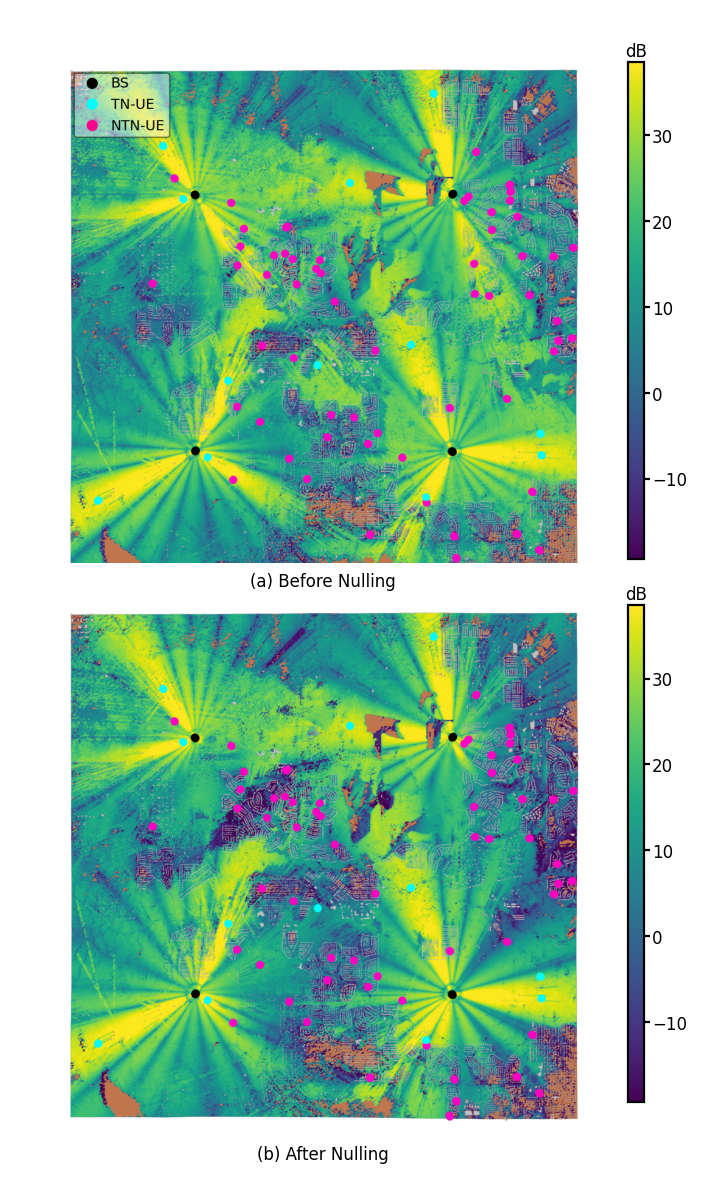

In [12]:
# Radiomap render settings
# Set the booleans below to choose which radiomap(s) to render.
run_radiomap_no_nulling = True
run_radiomap_music_est = False
run_radiomap_true_ug = True

radiomap_metric = "inr_ntn"
radiomap_cell_size = (1, 1)
radiomap_max_depth = 3
radiomap_samples_per_tx = 10**8
radiomap_render_resolution = (10000, 10000)
radiomap_render_num_samples = 16
radiomap_vmin = -25
radiomap_vmax = 45
radiomap_use_auto_contrast = True
radiomap_auto_contrast_percentiles = (2.0, 98.0)
radiomap_camera_pos = [0, 0, 10000]
radiomap_camera_look_at = [0, 0, 0]
radiomap_fov = 60
radiomap_terrain_name = "terrain"
radiomap_terrain_z_offset = 1.5

fallback_center = [0.0, 0.0, 1.5]
fallback_size = [
    float(SceneConfig.extent[1] - SceneConfig.extent[0]),
    float(SceneConfig.extent[3] - SceneConfig.extent[2]),
]

radiomap_specs = []
if run_radiomap_no_nulling:
    radiomap_specs.append(
        ("No Nulling", raw_precoding, result_dir / "radiomap_no_nulling.png", "no_nulling")
    )
if run_radiomap_music_est:
    radiomap_specs.append(
        (
            f"MUSIC Estimated (u, g) Nulling, lambda={lambda_key:.1e}",
            music_est_precoding,
            result_dir / "radiomap_music_est_nulling.png",
            "music_est",
        )
    )
if run_radiomap_true_ug:
    radiomap_specs.append(
        (
            f"True (u, g) Nulling, lambda={lambda_key:.1e}",
            music_true_precoding,
            result_dir / "radiomap_true_ug_nulling.png",
            "true_ug",
        )
    )

print("Radiomaps selected:")
for title, _precoding, _save_path, _tag in radiomap_specs:
    print(" -", title)
if len(radiomap_specs) == 0:
    print(" - none")

if not run_radiomap_no_nulling:
    raise ValueError("For the stacked 2x1 figure, set run_radiomap_no_nulling = True.")

secondary_specs = [spec for spec in radiomap_specs if spec[3] != "no_nulling"]
if len(secondary_specs) != 1:
    raise ValueError(
        "For the stacked 2x1 figure, select exactly one bottom panel: "
        "set exactly one of run_radiomap_music_est / run_radiomap_true_ug to True."
    )

selected_specs = [next(spec for spec in radiomap_specs if spec[3] == "no_nulling"), secondary_specs[0]]

radio_maps = {}
for title, precoding, _save_path, _tag in selected_specs:
    print("\n" + "=" * 80)
    print(f"Solving {title}")
    radio_maps[title] = _compute_nulling_radiomap(
        scene,
        precoding,
        cell_size=radiomap_cell_size,
        max_depth=radiomap_max_depth,
        samples_per_tx=radiomap_samples_per_tx,
        use_terrain=True,
        terrain_name=radiomap_terrain_name,
        terrain_z_offset=radiomap_terrain_z_offset,
        fallback_center=fallback_center,
        fallback_size=fallback_size,
    )

shared_vmin, shared_vmax = _resolve_shared_rm_limits(
    list(radio_maps.values()),
    radiomap_metric,
    rm_vmin=radiomap_vmin,
    rm_vmax=radiomap_vmax,
    auto_contrast=radiomap_use_auto_contrast,
    auto_contrast_percentiles=radiomap_auto_contrast_percentiles,
)

from tempfile import TemporaryDirectory

with TemporaryDirectory() as tmp_dir:
    panel_images = []
    for panel_idx, (title, _precoding, _save_path, _tag) in enumerate(selected_specs):
        panel_path = Path(tmp_dir) / f"panel_{panel_idx}.png"
        print(f"Rendering {title}")
        draw_nulling_radiomap(
            scene,
            radio_maps[title],
            metric=radiomap_metric,
            overlay_tn_pos=paired_tn_pos,
            overlay_ntn_pos=detected_ntn_pos,
            overlay_bs_pos=SceneConfig.tx_pos,
            camera_pos=radiomap_camera_pos,
            camera_look_at=radiomap_camera_look_at,
            render_resolution=radiomap_render_resolution,
            render_fov=radiomap_fov,
            render_num_samples=radiomap_render_num_samples,
            rm_vmin=shared_vmin,
            rm_vmax=shared_vmax,
            rm_cmap="viridis",
            show_color_bar=False,
            show_legend=(panel_idx == 0),
            legend_loc="upper left",
            legend_bbox_to_anchor=(0.055, 0.945),
            legend_framealpha=0.48,
            legend_fontsize=10,
            save_tight_bbox=False,
            show_plot=False,
            save_path=panel_path,
        )
        panel_images.append(plt.imread(panel_path))

fig = plt.figure(figsize=(3.35, 5.95), dpi=200)
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0], hspace=-0.12)
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

for ax, image in zip(axes, panel_images):
    ax.imshow(image)
    ax.axis("off")

fig.subplots_adjust(left=0.0, right=0.905, top=1.0, bottom=0.025, hspace=0.0)
fig.canvas.draw()

sm = ScalarMappable(norm=Normalize(vmin=shared_vmin, vmax=shared_vmax), cmap=plt.get_cmap("viridis"))
sm.set_array([])

for ax in axes:
    box = ax.get_position()
    cax = fig.add_axes([
        box.x1 + 0.002,
        box.y0 + 0.11 * box.height,
        0.024,
        0.82 * box.height,
    ])
    cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
    cbar.ax.set_title("dB", fontsize=6, pad=2)
    cbar.ax.tick_params(labelsize=6, pad=1, length=2)

label_specs = [
    (axes[0], "(a) Before Nulling", -0.045),
    (axes[1], "(b) After Nulling", -0.02),
]
for ax, label, label_y_offset in label_specs:
    box = ax.get_position()
    fig.text(
        0.5 * (box.x0 + box.x1),
        box.y0 - label_y_offset,
        label,
        ha="center",
        va="top",
        fontsize=6,
    )

secondary_tag = secondary_specs[0][3]
stacked_save_path = result_dir / f"radiomap_ieee_single_column2_{secondary_tag}.png"
fig.savefig(stacked_save_path, dpi=400, bbox_inches="tight", pad_inches=0.0)
print(f"saved: {stacked_save_path}")
plt.show()